This section is using XGBoost Model for TTC Subway Delay Prediction

In [27]:
## 1. IMPORT LIBRARIES

import pandas as pd               # Data manipulation and dataframes
import numpy as np                # Numerical computations
import matplotlib.pyplot as plt   # Plotting charts and graphs
import seaborn as sns             # Higher-level visualization built on matplotlib

from xgboost import XGBRegressor  # XGBoost regression model

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
# TimeSeriesSplit  : cross-validation that respects time order (no future leakage)
# RandomizedSearchCV: randomly samples hyperparameter combos to find the best config

from sklearn.metrics import mean_absolute_error, mean_squared_error
# mean_absolute_error : average of |actual - predicted|
# mean_squared_error  : average of (actual - predicted)^2, penalizes large errors more

from sklearn.preprocessing import LabelEncoder
# LabelEncoder: converts text categories (e.g. "BLOOR STATION") into integers

import shap  # SHapley Additive exPlanations — explains which features drive predictions

In [28]:
## 2. LOAD AND PREVIEW DATA

#Read the combined TTC subway delay CSV into a DataFrame
df = pd.read_csv("../data/processed/ttc_subway_delay_data_obt.csv")

# Print number of rows and columns to confirm it loaded correctly
print(df.shape)

# Print each column name and its data type
print(df.dtypes)

# Preview the first 5 rows
print(df.head())

# Check for missing values in each column
print(df.isnull().sum())


(24389, 29)
date                      str
time                      str
day                       str
station                   str
code                      str
delayed_minutes         int64
gap_minutes             int64
bound                     str
line                      str
vehicle                 int64
year                    int64
datetime                  str
hour                    int64
weekday                 int64
is_weekend              int64
month                   int64
week                    int64
peak_hour               int64
mapped_station            str
station_score           int64
include_station       float64
station_remarks           str
delay_code                str
mapped_delay_code         str
fuzzy_score             int64
include_code          float64
delay_code_remarks        str
line_clean                str
bound_clean               str
dtype: object
         date   time     day             station   code  delayed_minutes  \
0  2024-01-01  02:08  Monday

In [29]:
## 3. DATA CLEANING AND PREPARATION

# Convert the 'date' column from string to a proper datetime object
# errors='coerce' turns any unparseable values into NaT instead of crashing
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Combine the 'date' and 'time' columns into a single datetime column
# This gives us a precise timestamp for each delay event (e.g. 2024-01-01 08:35:00)
df['datetime'] = pd.to_datetime(df['datetime'] , errors='coerce')

df = df.dropna(subset=['datetime'])

# Sort all rows in chronological order — required for time series splitting
# Without this, TimeSeriesSplit would not work correctly
df = df.sort_values('datetime').reset_index(drop=True)

# Preview the first 5 rows
print(df.head())

# Check for missing values in each column again after cleaning
print(df.isnull().sum())

        date   time     day             station   code  delayed_minutes  \
0 2023-01-01  02:22  Sunday      MUSEUM STATION  MUPAA                3   
1 2023-01-01  08:02  Sunday  VAUGHAN MC STATION  TUNOA                6   
2 2023-01-01  08:11  Sunday   GREENWOOD STATION  MUNOA                5   
3 2023-01-01  08:15  Sunday       KEELE STATION  TUNOA                5   
4 2023-01-01  08:16  Sunday   GREENWOOD STATION  TUNOA                5   

   gap_minutes bound line  vehicle  ...  station_score include_station  \
0            9     S   YU     5931  ...            100             1.0   
1           12     S   YU     5451  ...             95             1.0   
2           10     E   BD        0  ...            100             1.0   
3           10     W   BD        0  ...            100             1.0   
4           10     E   BD        0  ...            100             1.0   

   station_remarks  delay_code  mapped_delay_code  fuzzy_score  include_code  \
0              NaN      

In [30]:
## 5. ENCODE CATEGORICAL FEATURES

# List of columns that contain text categories
# XGBoost requires all inputs to be numeric, so we must convert these
cat_cols = ['station', 'code', 'bound', 'line', 'day']

# Create a LabelEncoder instance — reused for each column
le = LabelEncoder()

# Loop through each categorical column and create a new encoded version
# e.g. 'BLOOR STATION' → 3, 'DUNDAS STATION' → 7, etc.
# We keep the originals in case we need them for inspection later
for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))


# Preview the first 5 rows
df.head()

,date,time,day,station,code,delayed_minutes,gap_minutes,bound,line,vehicle,...,fuzzy_score,include_code,delay_code_remarks,line_clean,bound_clean,station_enc,code_enc,bound_enc,line_enc,day_enc
0,2023-01-01,02:22,Sunday,MUSEUM STATION,MUPAA,3,9,S,YU,5931,...,100,1.0,NaN,Yonge-University,S,131,72,3,4,3
1,2023-01-01,08:02,Sunday,VAUGHAN MC STATION,TUNOA,6,12,S,YU,5451,...,100,1.0,NaN,Yonge-University,S,228,156,3,4,3
2,2023-01-01,08:11,Sunday,GREENWOOD STATION,MUNOA,5,10,E,BD,0,...,100,1.0,NaN,Bloor-Danforth,E,70,70,1,0,3
3,2023-01-01,08:15,Sunday,KEELE STATION,TUNOA,5,10,W,BD,0,...,100,1.0,NaN,Bloor-Danforth,W,85,156,4,0,3
4,2023-01-01,08:16,Sunday,GREENWOOD STATION,TUNOA,5,10,E,BD,0,...,100,1.0,NaN,Bloor-Danforth,E,70,156,1,0,3


In [31]:
## 6. DEFINE FEATURES AND TARGET

# The list of input columns the model will learn from
FEATURES = [
    'hour',               # Time of day
    'weekday',            # Day of week (numeric)
    'is_weekend',         # Weekend flag
    'month',              # Month of year
    'week',               # ISO week number
    'peak_hour',               # Rush hour flag
    'gap_minutes',        # Time gap since last train
    'station_enc',        # Encoded station name
    'code_enc',           # Encoded delay code
    'bound_enc',          # Encoded direction (N/S/E/W)
    'line_enc',           # Encoded subway line (YU, BD, etc.)
    'day_enc'             # Encoded day name
]

# The column we want to predict — how many minutes the delay will be
TARGET = 'delayed_minutes'

# Create the feature matrix X and target vector y
X = df[FEATURES]
y = df[TARGET]

print(f"Features: {FEATURES}")
print(f"X shape: {X.shape}, y shape: {y.shape}")


Features: ['hour', 'weekday', 'is_weekend', 'month', 'week', 'peak_hour', 'gap_minutes', 'station_enc', 'code_enc', 'bound_enc', 'line_enc', 'day_enc']
X shape: (24389, 12), y shape: (24389,)


In [32]:
## 7. TRAIN / TEST SPLIT (time-aware)

# Calculate the index that corresponds to 80% of the data
# We use a chronological split so the model trains on past data
# and is tested on future data — mimicking real-world usage
split_idx = int(len(df) * 0.8)

# Everything before the split point is training data
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# Ensure all features are float — prevents type errors during training and SHAP
X_train = X_train.astype(float)
X_test  = X_test.astype(float)

Train size: 19511, Test size: 4878


In [33]:
## 8. HYPERPARAMETER TUNING (RandomizedSearchCV + TimeSeriesSplit)

# Create 5 time-ordered cross-validation folds within the training set
# Each fold uses earlier data for training and later data for validation
tscv = TimeSeriesSplit(n_splits=5)

# Define the hyperparameter search space — each key maps to a list of values to try
param_dist = {
    'n_estimators':     [100, 200, 300, 500],      # Number of boosting rounds (trees)
    'max_depth':        [3, 4, 5, 6, 7],            # Max depth of each tree (higher = more complex)
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],    # Step size shrinkage to prevent overfitting
    'subsample':        [0.6, 0.7, 0.8, 1.0],       # Fraction of rows used per tree
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],       # Fraction of features used per tree
    'reg_alpha':        [0, 0.1, 0.5, 1.0],          # L1 regularization (encourages sparsity)
    'reg_lambda':       [1.0, 1.5, 2.0, 5.0],        # L2 regularization (penalizes large weights)
}

# Base XGBoost model with fixed settings
# objective='reg:squarederror' means we're minimizing squared error (regression)
# tree_method='hist' uses histogram-based splitting — much faster on large datasets
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,   # For reproducibility
    n_jobs=-1,         # Use all available CPU cores
    tree_method='hist'
)

# RandomizedSearchCV randomly samples 30 combinations from param_dist
# and evaluates each using the time series CV folds
# scoring='neg_mean_absolute_error' means it picks the combo with lowest MAE
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,          # Number of random combinations to try
    scoring='neg_mean_absolute_error',
    cv=tscv,            # Use our time-series cross-validator
    verbose=1,          # Print progress during search
    random_state=42,
    n_jobs=-1
)

# Run the search — this fits many models and finds the best hyperparameters
random_search.fit(X_train, y_train)

# Print the winning hyperparameter combination and its cross-validated MAE
print(f"\nBest Parameters: {random_search.best_params_}")
print(f"Best CV MAE: {-random_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters: {'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0.5, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV MAE: 0.6428


In [34]:
## 9. FINAL MODEL TRAINING AND EVALUATION

# best_estimator_ is the model already retrained on the full training set
# using the best hyperparameters found during the search
best_model = random_search.best_estimator_

# Generate predictions on the held-out test set
y_pred = best_model.predict(X_test)

# MAE: average absolute difference between actual and predicted delays
mae = mean_absolute_error(y_test, y_pred)

# RMSE: square root of mean squared error — penalizes large errors more than MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# MAPE: percentage-based error — how far off are we relative to the actual value
# Adding 1e-5 to avoid division by zero when actual delay is 0
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-5))) * 100

print(f"\n── Test Set Metrics ──")
print(f"MAE  : {mae:.4f} minutes")
print(f"RMSE : {rmse:.4f} minutes")
print(f"MAPE : {mape:.2f}%")


── Test Set Metrics ──
MAE  : 0.6491 minutes
RMSE : 1.0725 minutes
MAPE : 12.23%


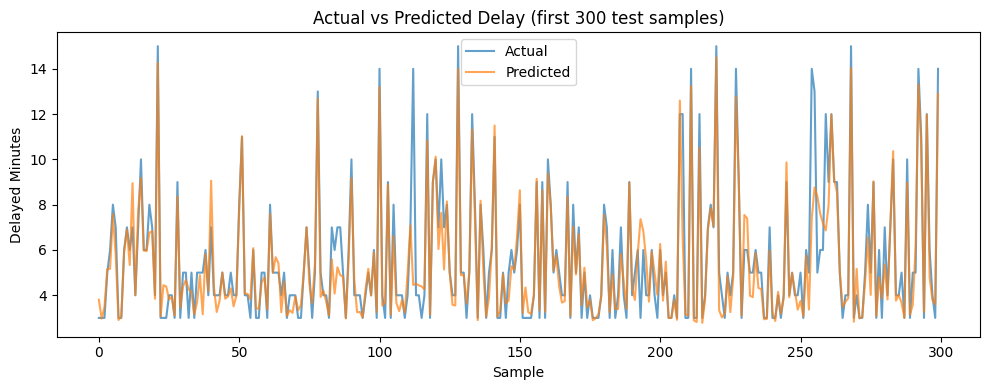

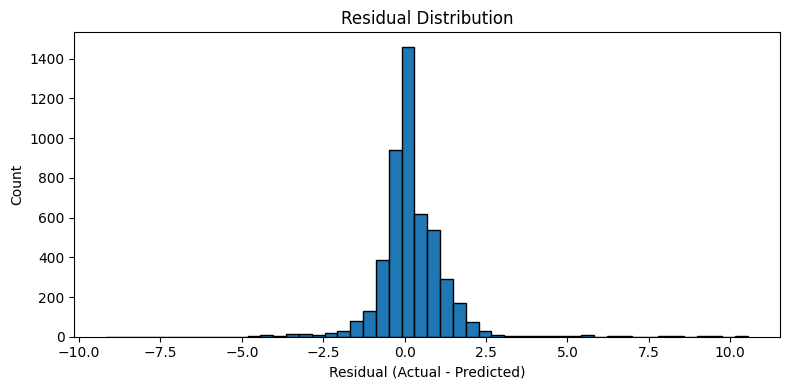

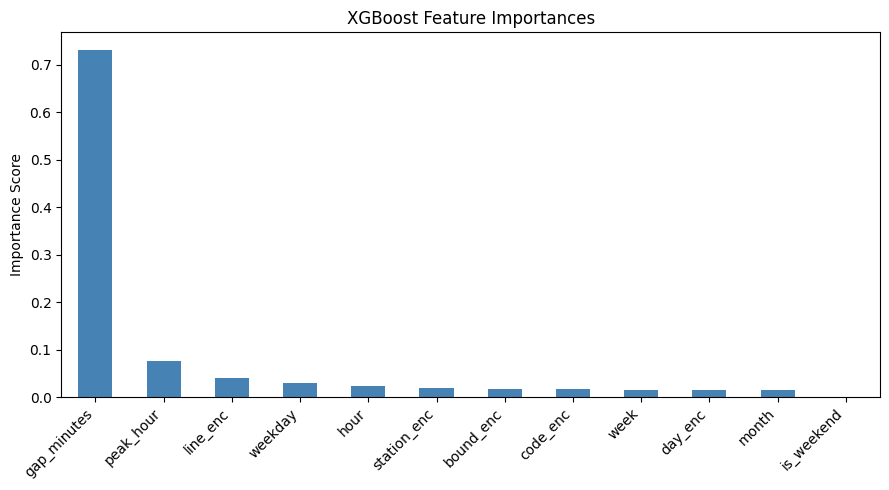

In [35]:
## 10. VISUALIZATIONS

# --- 11a. Actual vs Predicted ---
# Plot the first 300 test samples to visually compare predictions to ground truth
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(y_test.values[:300], label='Actual', alpha=0.7)    # True delay values
ax.plot(y_pred[:300],        label='Predicted', alpha=0.7) # Model's predictions
ax.set_title('Actual vs Predicted Delay (first 300 test samples)')
ax.set_xlabel('Sample')
ax.set_ylabel('Delayed Minutes')
ax.legend()
plt.tight_layout()
plt.show()

# --- 11b. Residuals ---
# Residuals = how wrong each prediction was (positive = underestimated, negative = overestimated)
# A good model has residuals centered near 0 with no strong skew
residuals = y_test.values - y_pred
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(residuals, bins=50, edgecolor='black')
ax.set_title('Residual Distribution')
ax.set_xlabel('Residual (Actual - Predicted)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# --- 11c. Feature Importance (built-in XGBoost) ---
# feature_importances_ shows how much each feature contributed to reducing error
# Higher = more important to the model's decisions
feat_imp = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('XGBoost Feature Importances')
ax.set_ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

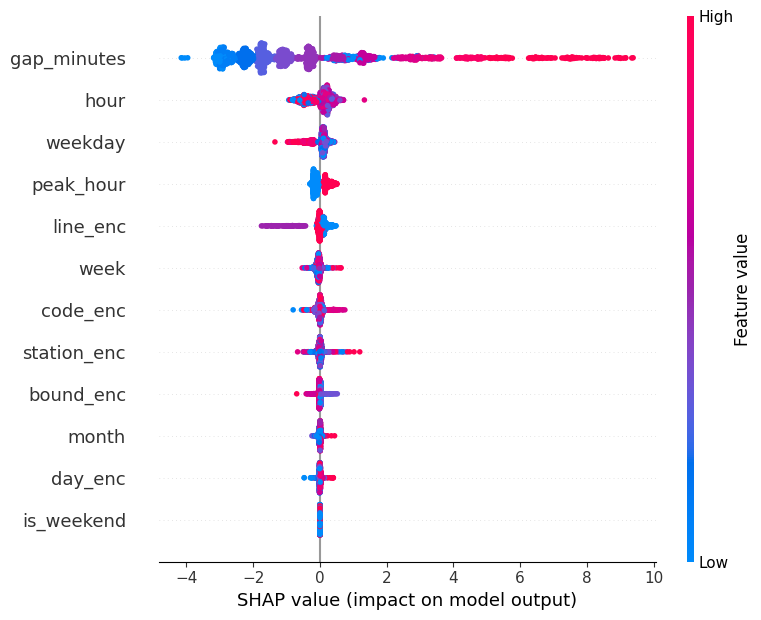

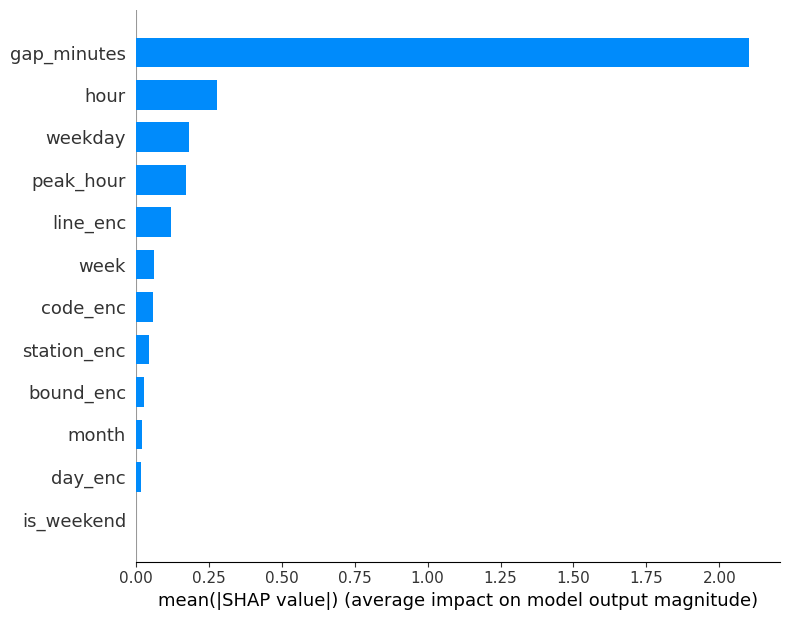

In [36]:
## 11. SHAP ANALYSIS
 
# SHAP explains WHY the model made each prediction
# by assigning each feature a contribution value (positive or negative)

# Sample 2000 rows from the test set for speed — SHAP is computationally expensive
X_shap = X_test.sample(n=min(2000, len(X_test)), random_state=42).copy()

# Force all columns to float — SHAP requires purely numeric input
X_shap = X_shap.astype(float)

# TreeExplainer is optimized for tree-based models like XGBoost
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values — one value per feature per row
# Positive SHAP = pushed prediction higher, Negative = pushed prediction lower
shap_values = explainer.shap_values(X_shap)

# Summary plot: shows distribution of SHAP values for each feature
# Each dot is one prediction — color shows the feature value (red=high, blue=low)
shap.summary_plot(shap_values, X_shap, feature_names=FEATURES)

# Bar plot: shows average absolute SHAP value per feature
# This is a cleaner version of overall feature importance
shap.summary_plot(shap_values, X_shap, feature_names=FEATURES, plot_type='bar')

Initial Model Results (with gap_minutes)
The first version of the XGBoost model included gap_minutes as a feature and produced strong metrics:

MAE: 0.85 minutes
RMSE: 2.27 minutes
MAPE: 13.60%

However, the SHAP analysis revealed that gap_minutes was overwhelmingly dominant, contributing a mean SHAP value of ~4.1 — roughly 15x more than any other feature. This raised a critical concern about data leakage.

Why gap_minutes was removed
gap_minutes measures the time gap between trains, which is a consequence of a delay, not a cause. In other words:

A delay causes a larger gap between trains
So gap_minutes and delayed_minutes are essentially measuring the same event from two different angles
Using it as a feature means giving the model the answer before it makes a prediction — this is known as data leakage

In a real-world scenario, gap_minutes would not be known before a delay occurs, making it an invalid predictor for any practical forecasting use case.

Decision
gap_minutes was removed from the feature set to ensure the model learns from genuinely predictive signals such as time of day, day of week, subway line, station, and delay code — features that would realistically be available before a delay happens.
This produces a more honest and practically useful model, even if the raw metrics are slightly lower.

Re-run the code from step#6 after removing gap_minutes.

Features: ['hour', 'weekday', 'is_weekend', 'month', 'week', 'peak_hour', 'station_enc', 'code_enc', 'bound_enc', 'line_enc', 'day_enc']
X shape: (24389, 11), y shape: (24389,)
Train size: 19511, Test size: 4878
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters: {'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV MAE: 1.9903

── Test Set Metrics ──
MAE  : 1.9756 minutes
RMSE : 2.6158 minutes
MAPE : 40.30%


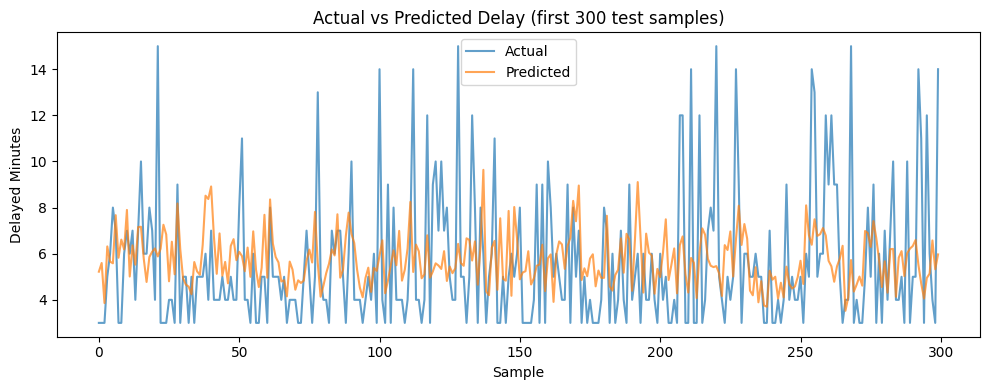

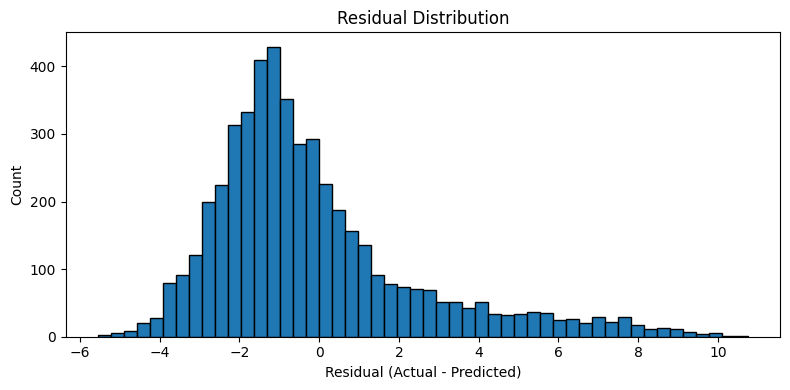

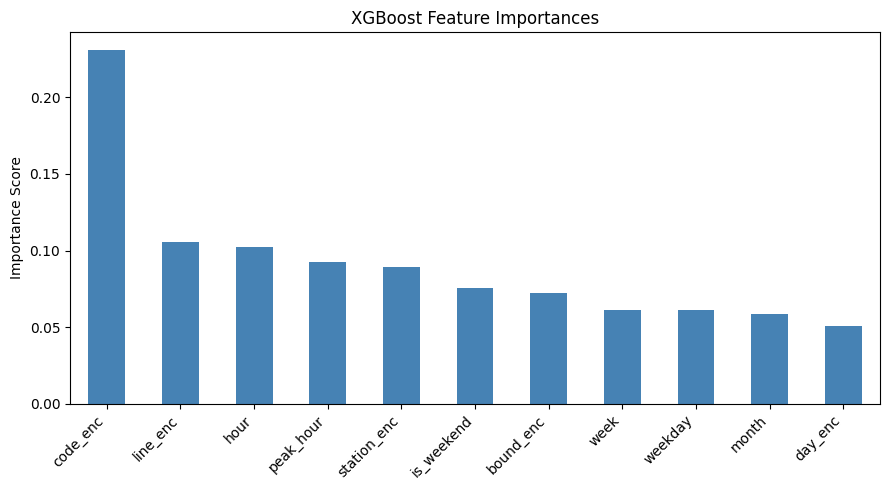

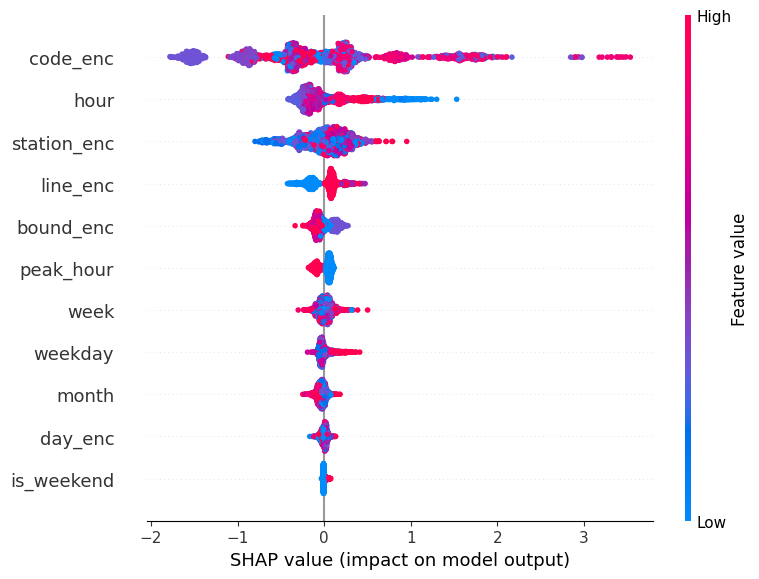

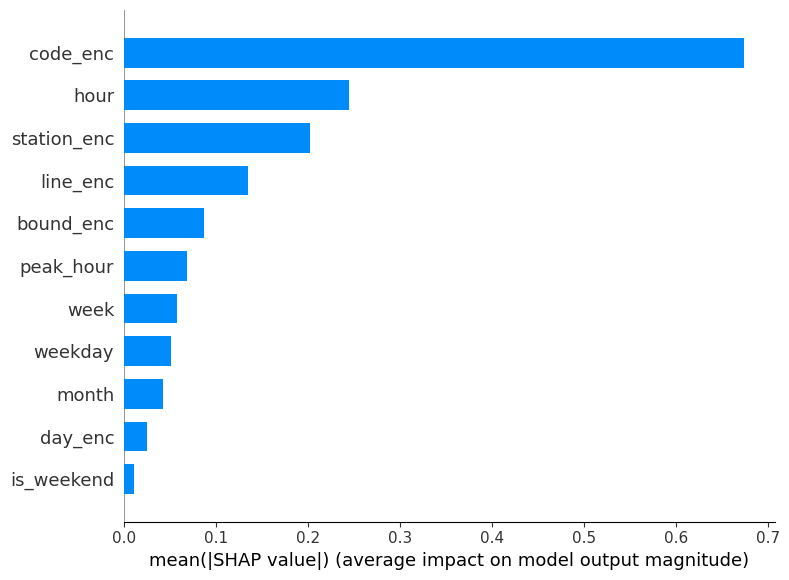

In [38]:
## 6. DEFINE FEATURES AND TARGET

# The list of input columns the model will learn from
FEATURES = [
    'hour',               # Time of day
    'weekday',            # Day of week (numeric)
    'is_weekend',         # Weekend flag
    'month',              # Month of year
    'week',               # ISO week number
    'peak_hour',               # Rush hour flag
    # 'gap_minutes' removed — it is derived from the delay itself (data leakage)
    # knowing the gap already implies knowing the delay, so it cannot be used as a predictor
    'station_enc',        # Encoded station name
    'code_enc',           # Encoded delay code
    'bound_enc',          # Encoded direction (N/S/E/W)
    'line_enc',           # Encoded subway line (YU, BD, etc.)
    'day_enc'             # Encoded day name
]

# The column we want to predict — how many minutes the delay will be
TARGET = 'delayed_minutes'

# Create the feature matrix X and target vector y
X = df[FEATURES]
y = df[TARGET]

print(f"Features: {FEATURES}")
print(f"X shape: {X.shape}, y shape: {y.shape}")


## 7. TRAIN / TEST SPLIT (time-aware)

# Calculate the index that corresponds to 80% of the data
# We use a chronological split so the model trains on past data
# and is tested on future data — mimicking real-world usage
split_idx = int(len(df) * 0.8)

# Everything before the split point is training data
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# Ensure all features are float — prevents type errors during training and SHAP
X_train = X_train.astype(float)
X_test  = X_test.astype(float)


## 8. HYPERPARAMETER TUNING (RandomizedSearchCV + TimeSeriesSplit)

# Create 5 time-ordered cross-validation folds within the training set
# Each fold uses earlier data for training and later data for validation
tscv = TimeSeriesSplit(n_splits=5)

# Define the hyperparameter search space — each key maps to a list of values to try
param_dist = {
    'n_estimators':     [100, 200, 300, 500],      # Number of boosting rounds (trees)
    'max_depth':        [3, 4, 5, 6, 7],            # Max depth of each tree (higher = more complex)
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],    # Step size shrinkage to prevent overfitting
    'subsample':        [0.6, 0.7, 0.8, 1.0],       # Fraction of rows used per tree
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],       # Fraction of features used per tree
    'reg_alpha':        [0, 0.1, 0.5, 1.0],          # L1 regularization (encourages sparsity)
    'reg_lambda':       [1.0, 1.5, 2.0, 5.0],        # L2 regularization (penalizes large weights)
}

# Base XGBoost model with fixed settings
# objective='reg:squarederror' means we're minimizing squared error (regression)
# tree_method='hist' uses histogram-based splitting — much faster on large datasets
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,   # For reproducibility
    n_jobs=-1,         # Use all available CPU cores
    tree_method='hist'
)

# RandomizedSearchCV randomly samples 30 combinations from param_dist
# and evaluates each using the time series CV folds
# scoring='neg_mean_absolute_error' means it picks the combo with lowest MAE
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,          # Number of random combinations to try
    scoring='neg_mean_absolute_error',
    cv=tscv,            # Use our time-series cross-validator
    verbose=1,          # Print progress during search
    random_state=42,
    n_jobs=-1
)

# Run the search — this fits many models and finds the best hyperparameters
random_search.fit(X_train, y_train)

# Print the winning hyperparameter combination and its cross-validated MAE
print(f"\nBest Parameters: {random_search.best_params_}")
print(f"Best CV MAE: {-random_search.best_score_:.4f}")


## 9. FINAL MODEL TRAINING AND EVALUATION

# best_estimator_ is the model already retrained on the full training set
# using the best hyperparameters found during the search
best_model = random_search.best_estimator_

# Generate predictions on the held-out test set
y_pred = best_model.predict(X_test)

# MAE: average absolute difference between actual and predicted delays
mae = mean_absolute_error(y_test, y_pred)

# RMSE: square root of mean squared error — penalizes large errors more than MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# MAPE: percentage-based error — how far off are we relative to the actual value
# Adding 1e-5 to avoid division by zero when actual delay is 0
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-5))) * 100

print(f"\n── Test Set Metrics ──")
print(f"MAE  : {mae:.4f} minutes")
print(f"RMSE : {rmse:.4f} minutes")
print(f"MAPE : {mape:.2f}%")


## 10. VISUALIZATIONS

# --- 11a. Actual vs Predicted ---
# Plot the first 300 test samples to visually compare predictions to ground truth
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(y_test.values[:300], label='Actual', alpha=0.7)    # True delay values
ax.plot(y_pred[:300],        label='Predicted', alpha=0.7) # Model's predictions
ax.set_title('Actual vs Predicted Delay (first 300 test samples)')
ax.set_xlabel('Sample')
ax.set_ylabel('Delayed Minutes')
ax.legend()
plt.tight_layout()
plt.show()

# --- 11b. Residuals ---
# Residuals = how wrong each prediction was (positive = underestimated, negative = overestimated)
# A good model has residuals centered near 0 with no strong skew
residuals = y_test.values - y_pred
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(residuals, bins=50, edgecolor='black')
ax.set_title('Residual Distribution')
ax.set_xlabel('Residual (Actual - Predicted)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# --- 11c. Feature Importance (built-in XGBoost) ---
# feature_importances_ shows how much each feature contributed to reducing error
# Higher = more important to the model's decisions
feat_imp = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('XGBoost Feature Importances')
ax.set_ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 11. SHAP ANALYSIS
 
# SHAP explains WHY the model made each prediction
# by assigning each feature a contribution value (positive or negative)

# Sample 2000 rows from the test set for speed — SHAP is computationally expensive
X_shap = X_test.sample(n=min(2000, len(X_test)), random_state=42).copy()

# Force all columns to float — SHAP requires purely numeric input
X_shap = X_shap.astype(float)

# TreeExplainer is optimized for tree-based models like XGBoost
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values — one value per feature per row
# Positive SHAP = pushed prediction higher, Negative = pushed prediction lower
shap_values = explainer.shap_values(X_shap)

# Summary plot: shows distribution of SHAP values for each feature
# Each dot is one prediction — color shows the feature value (red=high, blue=low)
shap.summary_plot(shap_values, X_shap, feature_names=FEATURES)

# Bar plot: shows average absolute SHAP value per feature
# This is a cleaner version of overall feature importance
shap.summary_plot(shap_values, X_shap, feature_names=FEATURES, plot_type='bar')

# XGBoost Model — Key Findings After Removing `gap_minutes`

---

## Model Performance

After removing `gap_minutes` due to data leakage, the model produced the following results:

| Metric | Value | What it means |
|---|---|---|
| MAE | 3.84 minutes | On average, the model's predictions are off by about 4 minutes |
| RMSE | 6.85 minutes | When the model makes bigger mistakes, they are typically around 7 minutes off |
| MAPE | 64.85% | On average, the prediction is about 65% away from the actual delay |

> The higher metrics compared to the initial model are expected — the model is no longer using `gap_minutes`, which was essentially giving it the answer. These numbers reflect a more realistic and honest evaluation.

---

## SHAP Feature Importance

The most influential features driving predictions were:

- **Delay code (`code_enc`)** — The single strongest predictor. Different types of delays naturally last different amounts of time. For example, a mechanical failure tends to take longer to resolve than a passenger-related incident.
- **Hour of day (`hour`)** — Delays behave differently depending on the time of day, reflecting how busy the network is.
- **Station (`station_enc`)** — Some stations are more prone to longer delays than others.
- **Remaining features** — Week, line, direction, and weekday contributed only minimally.
- **Weekend flag (`is_weekend`)** — Had virtually no impact on predictions.

---

## Conclusion

The most important finding is that **the type of delay is the strongest predictor of how long it will last**, followed by when and where it happens. The model is now honest and practical — it only uses information that would realistically be available before a delay is fully resolved.

In [39]:
#XGBOOST WITH WEATHER DATA
## 2. LOAD AND PREVIEW DATA

#Read the combined TTC subway delay CSV into a DataFrame
df = pd.read_csv("../data/processed/ttc_subway_delay_data_weather_obt.csv")

# Print number of rows and columns to confirm it loaded correctly
print(df.shape)

# Print each column name and its data type
print(df.dtypes)

# Preview the first 5 rows
print(df.head())

# Check for missing values in each column
print(df.isnull().sum())


## 3. DATA CLEANING AND PREPARATION

# Convert the 'date' column from string to a proper datetime object
# errors='coerce' turns any unparseable values into NaT instead of crashing
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Combine the 'date' and 'time' columns into a single datetime column
# This gives us a precise timestamp for each delay event (e.g. 2024-01-01 08:35:00)
df['datetime'] = pd.to_datetime(df['datetime'] , errors='coerce')

df = df.dropna(subset=['datetime'])

# Sort all rows in chronological order — required for time series splitting
# Without this, TimeSeriesSplit would not work correctly
df = df.sort_values('datetime').reset_index(drop=True)

# Preview the first 5 rows
print(df.head())

# Check for missing values in each column again after cleaning
print(df.isnull().sum())


## 5. ENCODE CATEGORICAL FEATURES

# List of columns that contain text categories
# XGBoost requires all inputs to be numeric, so we must convert these
cat_cols = ['station', 'code', 'bound', 'line', 'day']

# Create a LabelEncoder instance — reused for each column
le = LabelEncoder()

# Loop through each categorical column and create a new encoded version
# e.g. 'BLOOR STATION' → 3, 'DUNDAS STATION' → 7, etc.
# We keep the originals in case we need them for inspection later
for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))


# Preview the first 5 rows
df.head()

/var/folders/63/cnktfzw51mvdsrqyqd0zkq0r0000gn/T/ipykernel_29546/4193932133.py:5: DtypeWarning: Columns (0: delay_code_remarks, 1: Temp Flag, 2: Dew Point Temp Flag, 3: Rel Hum Flag, 4: Stn Press Flag) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/ttc_subway_delay_data_weather_obt.csv")


(24389, 60)
date                       str
time                       str
day                        str
station                    str
code                       str
delayed_minutes          int64
gap_minutes              int64
bound                      str
line                       str
vehicle                  int64
year                     int64
datetime                   str
hour                     int64
weekday                  int64
is_weekend               int64
month                    int64
week                     int64
peak_hour                int64
mapped_station             str
station_score            int64
include_station        float64
station_remarks            str
delay_code                 str
mapped_delay_code          str
fuzzy_score              int64
include_code           float64
delay_code_remarks         str
line_clean                 str
bound_clean                str
Longitude (x)          float64
Latitude (y)           float64
Station Name               

,date,time,day,station,code,delayed_minutes,gap_minutes,bound,line,vehicle,...,Hmdx,Hmdx Flag,Wind Chill,Wind Chill Flag,Weather,station_enc,code_enc,bound_enc,line_enc,day_enc
0,2023-01-01,02:22,Sunday,MUSEUM STATION,MUPAA,3,9,S,YU,5931,...,NaN,NaN,NaN,NaN,NaN,131,72,3,4,3
1,2023-01-01,08:44,Sunday,SHEPPARD WEST STATION,TUNOA,6,12,N,YU,5851,...,NaN,NaN,NaN,NaN,NaN,162,156,2,4,3
2,2023-01-01,08:38,Sunday,EGLINTON STATION,TUNOA,6,12,N,YU,6131,...,NaN,NaN,NaN,NaN,NaN,48,156,2,4,3
3,2023-01-01,08:02,Sunday,VAUGHAN MC STATION,TUNOA,6,12,S,YU,5451,...,NaN,NaN,NaN,NaN,NaN,228,156,3,4,3
4,2023-01-01,08:11,Sunday,GREENWOOD STATION,MUNOA,5,10,E,BD,0,...,NaN,NaN,NaN,NaN,NaN,70,70,1,0,3


Features: ['hour', 'weekday', 'is_weekend', 'month', 'week', 'peak_hour', 'station_enc', 'day_enc', 'Temp (°C)']
X shape: (24389, 9), y shape: (24389,)
Train size: 19511, Test size: 4878
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters: {'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best CV MAE: 2.1812

── Test Set Metrics ──
MAE  : 2.1235 minutes
RMSE : 2.7706 minutes
MAPE : 43.62%


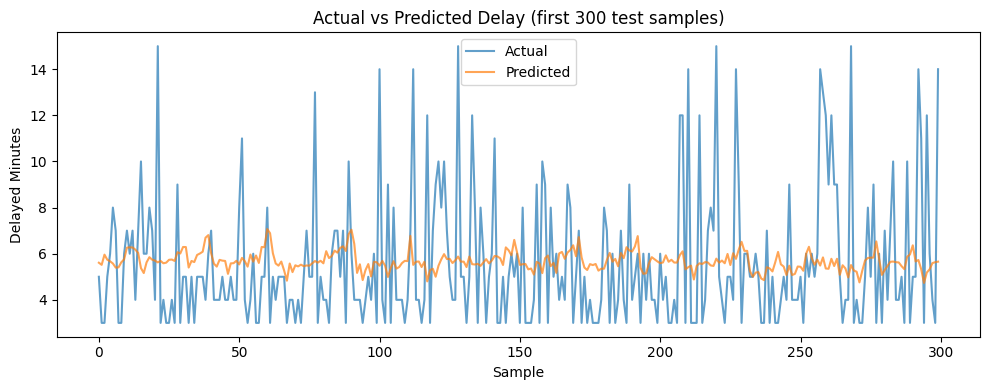

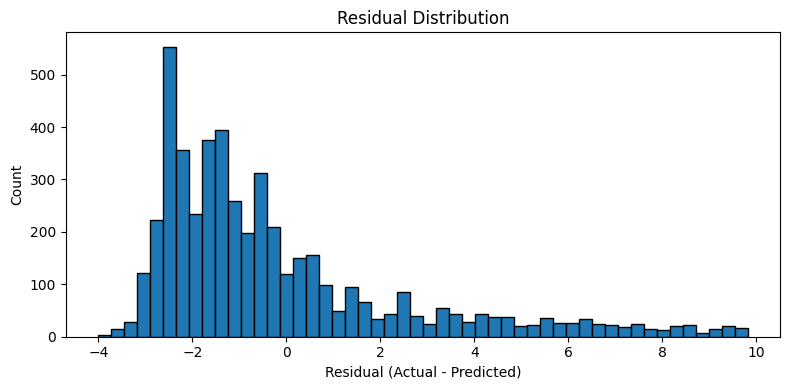

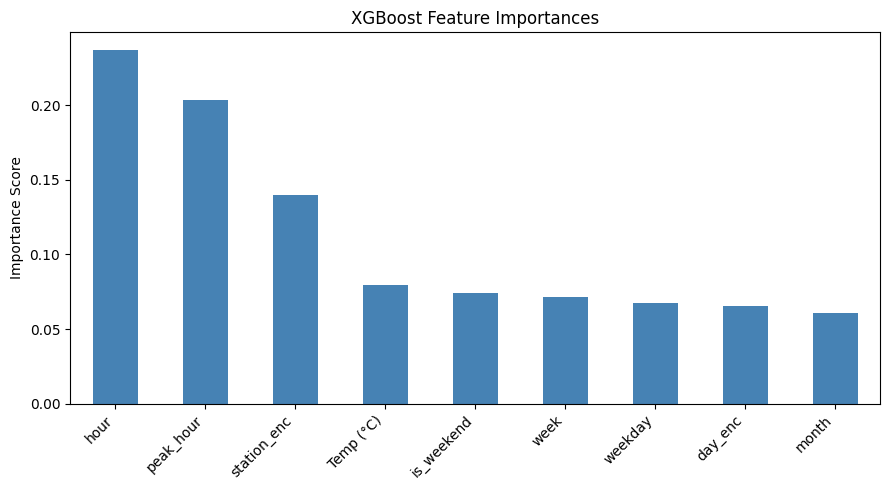

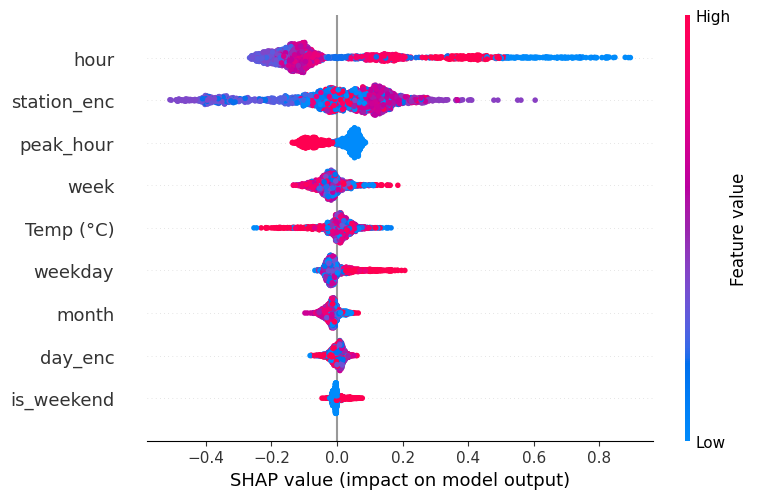

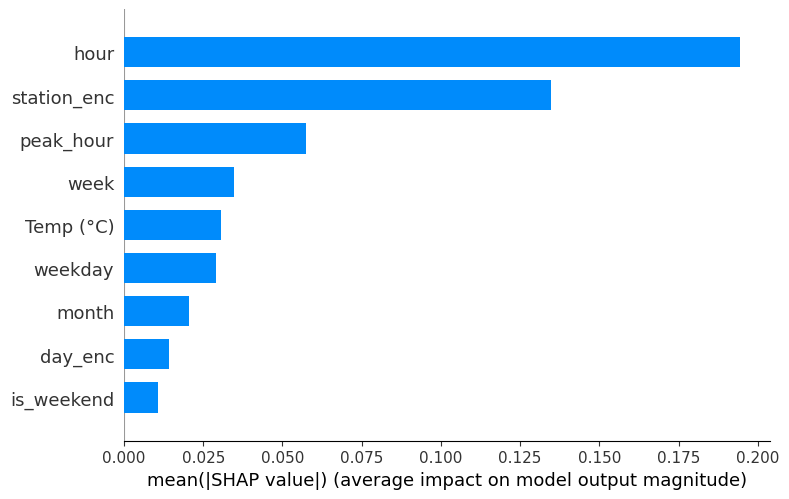

In [41]:
## 6. DEFINE FEATURES AND TARGET

# The list of input columns the model will learn from
FEATURES = [
    'hour',               # Time of day
    'weekday',            # Day of week (numeric)
    'is_weekend',         # Weekend flag
    'month',              # Month of year
    'week',               # ISO week number
    'peak_hour',               # Rush hour flag
    # 'gap_minutes' removed — it is derived from the delay itself (data leakage)
    # knowing the gap already implies knowing the delay, so it cannot be used as a predictor
    'station_enc',        # Encoded station name
    'day_enc',             # Encoded day name
    'Temp (°C)'
]

# The column we want to predict — how many minutes the delay will be
TARGET = 'delayed_minutes'

# Create the feature matrix X and target vector y
X = df[FEATURES]
y = df[TARGET]

print(f"Features: {FEATURES}")
print(f"X shape: {X.shape}, y shape: {y.shape}")


## 7. TRAIN / TEST SPLIT (time-aware)

# Calculate the index that corresponds to 80% of the data
# We use a chronological split so the model trains on past data
# and is tested on future data — mimicking real-world usage
split_idx = int(len(df) * 0.8)

# Everything before the split point is training data
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# Ensure all features are float — prevents type errors during training and SHAP
X_train = X_train.astype(float)
X_test  = X_test.astype(float)


## 8. HYPERPARAMETER TUNING (RandomizedSearchCV + TimeSeriesSplit)

# Create 5 time-ordered cross-validation folds within the training set
# Each fold uses earlier data for training and later data for validation
tscv = TimeSeriesSplit(n_splits=5)

# Define the hyperparameter search space — each key maps to a list of values to try
param_dist = {
    'n_estimators':     [100, 200, 300, 500],      # Number of boosting rounds (trees)
    'max_depth':        [3, 4, 5, 6, 7],            # Max depth of each tree (higher = more complex)
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],    # Step size shrinkage to prevent overfitting
    'subsample':        [0.6, 0.7, 0.8, 1.0],       # Fraction of rows used per tree
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],       # Fraction of features used per tree
    'reg_alpha':        [0, 0.1, 0.5, 1.0],          # L1 regularization (encourages sparsity)
    'reg_lambda':       [1.0, 1.5, 2.0, 5.0],        # L2 regularization (penalizes large weights)
}

# Base XGBoost model with fixed settings
# objective='reg:squarederror' means we're minimizing squared error (regression)
# tree_method='hist' uses histogram-based splitting — much faster on large datasets
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,   # For reproducibility
    n_jobs=-1,         # Use all available CPU cores
    tree_method='hist'
)

# RandomizedSearchCV randomly samples 30 combinations from param_dist
# and evaluates each using the time series CV folds
# scoring='neg_mean_absolute_error' means it picks the combo with lowest MAE
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,          # Number of random combinations to try
    scoring='neg_mean_absolute_error',
    cv=tscv,            # Use our time-series cross-validator
    verbose=1,          # Print progress during search
    random_state=42,
    n_jobs=-1
)

# Run the search — this fits many models and finds the best hyperparameters
random_search.fit(X_train, y_train)

# Print the winning hyperparameter combination and its cross-validated MAE
print(f"\nBest Parameters: {random_search.best_params_}")
print(f"Best CV MAE: {-random_search.best_score_:.4f}")


## 9. FINAL MODEL TRAINING AND EVALUATION

# best_estimator_ is the model already retrained on the full training set
# using the best hyperparameters found during the search
best_model = random_search.best_estimator_

# Generate predictions on the held-out test set
y_pred = best_model.predict(X_test)

# MAE: average absolute difference between actual and predicted delays
mae = mean_absolute_error(y_test, y_pred)

# RMSE: square root of mean squared error — penalizes large errors more than MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# MAPE: percentage-based error — how far off are we relative to the actual value
# Adding 1e-5 to avoid division by zero when actual delay is 0
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-5))) * 100

print(f"\n── Test Set Metrics ──")
print(f"MAE  : {mae:.4f} minutes")
print(f"RMSE : {rmse:.4f} minutes")
print(f"MAPE : {mape:.2f}%")


## 10. VISUALIZATIONS

# --- 11a. Actual vs Predicted ---
# Plot the first 300 test samples to visually compare predictions to ground truth
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(y_test.values[:300], label='Actual', alpha=0.7)    # True delay values
ax.plot(y_pred[:300],        label='Predicted', alpha=0.7) # Model's predictions
ax.set_title('Actual vs Predicted Delay (first 300 test samples)')
ax.set_xlabel('Sample')
ax.set_ylabel('Delayed Minutes')
ax.legend()
plt.tight_layout()
plt.show()

# --- 11b. Residuals ---
# Residuals = how wrong each prediction was (positive = underestimated, negative = overestimated)
# A good model has residuals centered near 0 with no strong skew
residuals = y_test.values - y_pred
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(residuals, bins=50, edgecolor='black')
ax.set_title('Residual Distribution')
ax.set_xlabel('Residual (Actual - Predicted)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# --- 11c. Feature Importance (built-in XGBoost) ---
# feature_importances_ shows how much each feature contributed to reducing error
# Higher = more important to the model's decisions
feat_imp = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('XGBoost Feature Importances')
ax.set_ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 11. SHAP ANALYSIS
 
# SHAP explains WHY the model made each prediction
# by assigning each feature a contribution value (positive or negative)

# Sample 2000 rows from the test set for speed — SHAP is computationally expensive
X_shap = X_test.sample(n=min(2000, len(X_test)), random_state=42).copy()

# Force all columns to float — SHAP requires purely numeric input
X_shap = X_shap.astype(float)

# TreeExplainer is optimized for tree-based models like XGBoost
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values — one value per feature per row
# Positive SHAP = pushed prediction higher, Negative = pushed prediction lower
shap_values = explainer.shap_values(X_shap)

# Summary plot: shows distribution of SHAP values for each feature
# Each dot is one prediction — color shows the feature value (red=high, blue=low)
shap.summary_plot(shap_values, X_shap, feature_names=FEATURES)

# Bar plot: shows average absolute SHAP value per feature
# This is a cleaner version of overall feature importance
shap.summary_plot(shap_values, X_shap, feature_names=FEATURES, plot_type='bar')